In [1]:
import numpy as np
import pandas as pd

lob = pd.read_csv("lob.csv")
trades = pd.read_csv("trades.csv")

lob["bid"] = lob["bids[0].price"]
lob["ask"] = lob["asks[0].price"]

lob["bid_vol"] = lob["bids[0].amount"]
lob["ask_vol"] = lob["asks[0].amount"]

lob["mid"] = (lob["bid"] + lob["ask"]) / 2
lob["spread"] = lob["ask"] - lob["bid"]

tick_size = lob["spread"].replace(0, np.nan).median()

lob["microprice"] = (
    lob["ask"] * lob["bid_vol"] +
    lob["bid"] * lob["ask_vol"]
) / (lob["bid_vol"] + lob["ask_vol"] + 1e-9)

lob["imbalance_1"] = (
    lob["bid_vol"] - lob["ask_vol"]
) / (lob["bid_vol"] + lob["ask_vol"] + 1e-9)

lob["mid_ret"] = lob["mid"].pct_change()
lob["vol"] = lob["mid_ret"].rolling(200).std().fillna(0)

print("LOB shape:", lob.shape)
print("Trades shape:", trades.shape)
print("Tick size:", tick_size)

display(lob[[
    "local_timestamp", "bid", "ask", "mid",
    "spread", "microprice", "imbalance_1", "vol"
]].head())

display(trades.head())

LOB shape: (1036690, 112)
Trades shape: (21864989, 5)
Tick size: 9.999999999940612e-08


,local_timestamp,bid,ask,mid,spread,microprice,imbalance_1,vol
0,1722470402038431,0.011043,0.011044,0.011044,1.000000e-07,0.011044,-0.079070,0.0
1,1722470402305331,0.011043,0.011044,0.011044,1.000000e-07,0.011044,-0.094567,0.0
2,1722470403485121,0.011041,0.011041,0.011041,1.000000e-07,0.011041,0.849242,0.0
3,1722470403950214,0.011042,0.011042,0.011042,1.000000e-07,0.011042,0.866535,0.0
4,1722470404424495,0.011042,0.011042,0.011042,1.000000e-07,0.011042,-0.861301,0.0


,Unnamed: 0,local_timestamp,side,price,amount
0,0,1722470400014926,sell,0.011043,734
1,1,1722470402982045,sell,0.011043,1633
2,2,1722470402982047,sell,0.011043,25445
3,3,1722470402996765,sell,0.011043,4471
4,4,1722470403047136,buy,0.011044,5378


In [2]:
lob[["mid", "spread", "microprice", "imbalance_1", "vol"]].describe()

,mid,spread,microprice,imbalance_1,vol
count,1.036690e+06,1.036690e+06,1.036690e+06,1.036690e+06,1.036690e+06
mean,8.780237e-03,1.740869e-07,8.780237e-03,1.344298e-03,2.127373e-04
std,1.266578e-03,4.074543e-07,1.266578e-03,6.997239e-01,1.538802e-04
min,5.850600e-03,1.000000e-07,5.850400e-03,-9.999979e-01,0.000000e+00
25%,7.827600e-03,1.000000e-07,7.827600e-03,-6.908316e-01,1.180927e-04
50%,8.602150e-03,1.000000e-07,8.602136e-03,2.090448e-03,1.731490e-04
75%,9.985750e-03,1.000000e-07,9.985701e-03,6.932102e-01,2.583682e-04
max,1.114405e-02,6.920000e-05,1.114409e-02,9.999991e-01,2.939424e-03


In [3]:

levels_list = [5, 10, 20, 25]

for L in levels_list:
    
    bid_cols = [f"bids[{i}].amount" for i in range(L)]
    ask_cols = [f"asks[{i}].amount" for i in range(L)]

    bid_sum = lob[bid_cols].sum(axis=1)
    ask_sum = lob[ask_cols].sum(axis=1)

    lob[f"imbalance_{L}"] = (
        bid_sum - ask_sum
    ) / (bid_sum + ask_sum + 1e-9)

    lob[f"bid_ask_ratio_{L}"] = (
        bid_sum + 1e-9
    ) / (ask_sum + 1e-9)

    lob[f"imbalance_{L}_avg"] = (
        lob[f"imbalance_{L}"]
        .ewm(span=200, adjust=False)
        .mean()
    )

    lob[f"bid_ask_ratio_{L}_avg"] = (
        lob[f"bid_ask_ratio_{L}"]
        .ewm(span=200, adjust=False)
        .mean()
    )

feature_cols = []

for L in levels_list:
    feature_cols += [
        f"imbalance_{L}",
        f"bid_ask_ratio_{L}",
        f"imbalance_{L}_avg",
        f"bid_ask_ratio_{L}_avg",
    ]

print("Number of features:", len(feature_cols))

display(lob[feature_cols].head())

Number of features: 16


,imbalance_5,bid_ask_ratio_5,imbalance_5_avg,bid_ask_ratio_5_avg,imbalance_10,bid_ask_ratio_10,imbalance_10_avg,bid_ask_ratio_10_avg,imbalance_20,bid_ask_ratio_20,imbalance_20_avg,bid_ask_ratio_20_avg,imbalance_25,bid_ask_ratio_25,imbalance_25_avg,bid_ask_ratio_25_avg
0,0.443085,2.591214,0.443085,2.591214,0.317768,1.931554,0.317768,1.931554,0.057490,1.121992,0.057490,1.121992,-0.296946,0.542084,-0.296946,0.542084
1,0.441226,2.579266,0.443067,2.591095,0.316729,1.927095,0.317758,1.931510,0.056829,1.120506,0.057483,1.121978,-0.297455,0.541479,-0.296952,0.542078
2,0.635494,4.486884,0.444982,2.609959,0.098979,1.219704,0.315581,1.924427,-0.084646,0.843919,0.056069,1.119211,-0.111234,0.799800,-0.295104,0.544642
3,0.094923,1.209757,0.441498,2.596027,0.137257,1.318187,0.313806,1.918395,0.123740,1.282428,0.056742,1.120835,0.161313,1.384680,-0.290562,0.553001
4,-0.696774,0.178707,0.430172,2.571974,-0.411432,0.417001,0.306590,1.903456,-0.208476,0.654976,0.054103,1.116200,-0.266807,0.578772,-0.290326,0.553257


In [4]:
trades["signed_amount"] = np.where(
    trades["side"] == "buy",
    trades["amount"],
    -trades["amount"]
)

trades["notional"] = trades["price"] * trades["amount"]

trades["signed_notional"] = np.where(
    trades["side"] == "buy",
    trades["notional"],
    -trades["notional"]
)

lob_times = lob["local_timestamp"].values

idx = np.searchsorted(
    lob_times,
    trades["local_timestamp"].values,
    side="right"
) - 1

valid = (idx >= 0) & (idx < len(lob))

trades_tmp = trades.loc[valid].copy()
trades_tmp["lob_idx"] = idx[valid]

trade_features = trades_tmp.groupby("lob_idx").agg(
    trade_count=("amount", "count"),
    total_volume=("amount", "sum"),
    signed_volume=("signed_amount", "sum"),
    total_notional=("notional", "sum"),
    signed_notional=("signed_notional", "sum"),
).reset_index()

lob["lob_idx"] = lob.index

lob = lob.merge(
    trade_features,
    on="lob_idx",
    how="left"
)

trade_cols = [
    "trade_count",
    "total_volume",
    "signed_volume",
    "total_notional",
    "signed_notional"
]

for c in trade_cols:
    lob[c] = lob[c].fillna(0)


lob["trade_imbalance"] = (
    lob["signed_volume"]
    / (lob["total_volume"] + 1e-9)
)

lob["notional_imbalance"] = (
    lob["signed_notional"]
    / (lob["total_notional"] + 1e-9)
)

lob["trade_imbalance_avg"] = (
    lob["trade_imbalance"]
    .ewm(span=100, adjust=False)
    .mean()
)

lob["notional_imbalance_avg"] = (
    lob["notional_imbalance"]
    .ewm(span=100, adjust=False)
    .mean()
)

display(lob[[
    "trade_count",
    "trade_imbalance",
    "trade_imbalance_avg",
    "notional_imbalance",
    "notional_imbalance_avg"
]].head())

,trade_count,trade_imbalance,trade_imbalance_avg,notional_imbalance,notional_imbalance_avg
0,0.0,0.000000,0.000000,0.000000,0.000000
1,43.0,-0.915665,-0.018132,-0.915648,-0.018132
2,7.0,1.000000,0.002029,1.000000,0.002029
3,1.0,-1.000000,-0.017813,-1.000000,-0.017813
4,33.0,-0.972780,-0.036723,-0.972777,-0.036723


In [6]:
signal_cols = [
    "trade_imbalance",
    "trade_imbalance_avg",
    "notional_imbalance",
    "notional_imbalance_avg",

    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_20",
    "imbalance_25",

    "imbalance_5_avg",
    "imbalance_10_avg",
    "imbalance_20_avg",
    "imbalance_25_avg",
]

for c in signal_cols:
    lob[f"{c}_lag1"] = lob[c].shift(1)

horizon = 1

lob["future_mid_return"] = (
    lob["mid"].shift(-horizon) - lob["mid"]
) / lob["mid"]


corr_df_lagged = pd.DataFrame({
    "feature": [f"{c}_lag1" for c in signal_cols],
    "corr_future_return": [
        lob[f"{c}_lag1"].corr(lob["future_mid_return"])
        for c in signal_cols
    ]
})

corr_df_lagged["abs_corr"] = (
    corr_df_lagged["corr_future_return"].abs()
)

corr_df_lagged = corr_df_lagged.sort_values(
    "abs_corr",
    ascending=False
).reset_index(drop=True)

corr_df_lagged

,feature,corr_future_return,abs_corr
0,imbalance_5_lag1,0.022770,0.022770
1,imbalance_10_lag1,0.021452,0.021452
2,imbalance_1_lag1,0.019371,0.019371
3,imbalance_20_lag1,0.016887,0.016887
4,notional_imbalance_lag1,0.016259,0.016259
5,trade_imbalance_lag1,0.016259,0.016259
6,imbalance_25_lag1,0.014552,0.014552
7,notional_imbalance_avg_lag1,0.003913,0.003913
8,trade_imbalance_avg_lag1,0.003911,0.003911
9,imbalance_5_avg_lag1,0.002176,0.002176


In [7]:
lob["alpha_signal"] = (
    0.35 * lob["imbalance_5_lag1"] +
    0.25 * lob["imbalance_10_lag1"] +
    0.20 * lob["imbalance_1_lag1"] +
    0.20 * lob["trade_imbalance_lag1"]
)

lob["alpha_signal"] = np.tanh(
    lob["alpha_signal"]
)

print(
    "Signal correlation:",
    lob["alpha_signal"].corr(
        lob["future_mid_return"]
    )
)

lob[[
    "alpha_signal",
    "future_mid_return"
]].head()

Signal correlation: 0.027693947481105815


,alpha_signal,future_mid_return
0,NaN,0.000000
1,0.215286,-0.000254
2,0.031555,0.000109
3,0.549047,0.000000
4,0.040822,-0.000226


In [8]:
class Backtester:

    def __init__(self, lob):

        self.lob = lob

        self.inventory = 0.0
        self.cash = 0.0

        self.bid_order = None
        self.ask_order = None

        self.trades = []

        self.inventory_curve = []
        self.cash_curve = []
        self.equity_curve = []

    def place_orders(
        self,
        bid_price,
        ask_price,
        size=1.0
    ):
        self.bid_order = (bid_price, size)
        self.ask_order = (ask_price, size)

    def cancel_orders(self):

        self.bid_order = None
        self.ask_order = None

    def process_fills(
        self,
        next_bid,
        next_ask,
        t
    ):

        if self.bid_order is not None:

            price, size = self.bid_order

            if next_ask <= price:

                self.inventory += size
                self.cash -= price * size

                self.trades.append(
                    ("buy", price, size, t)
                )

                self.bid_order = None

        if self.ask_order is not None:

            price, size = self.ask_order

            if next_bid >= price:

                self.inventory -= size
                self.cash += price * size

                self.trades.append(
                    ("sell", price, size, t)
                )

                self.ask_order = None

    def mark_to_market(
        self,
        mid_price
    ):

        equity = (
            self.cash
            + self.inventory * mid_price
        )

        self.inventory_curve.append(
            self.inventory
        )

        self.cash_curve.append(
            self.cash
        )

        self.equity_curve.append(
            equity
        )

    def run(
        self,
        strategy
    ):

        for t in range(len(self.lob) - 1):

            row = self.lob.iloc[t]
            next_row = self.lob.iloc[t + 1]

            bid_quote, ask_quote = strategy(
                row,
                self.inventory
            )

            self.cancel_orders()

            self.place_orders(
                bid_quote,
                ask_quote
            )

            self.process_fills(
                next_row["bid"],
                next_row["ask"],
                t + 1
            )

            self.mark_to_market(
                next_row["mid"]
            )

        final_mid = self.lob.iloc[-1]["mid"]

        pnl = (
            self.cash
            + self.inventory * final_mid
        )

        turnover = sum(
            abs(price * size)
            for _, price, size, _
            in self.trades
        )

        return {

            "pnl": pnl,

            "inventory": self.inventory,

            "turnover": turnover,

            "trades": self.trades,

            "inventory_curve": self.inventory_curve,

            "cash_curve": self.cash_curve,

            "equity_curve": self.equity_curve,
        }

In [9]:
def dummy_strategy(row, inventory):
    bid_quote = row["bid"]
    ask_quote = row["ask"]
    return bid_quote, ask_quote


bt = Backtester(lob)
res_dummy = bt.run(dummy_strategy)

print("Dummy strategy")
print("PnL:", res_dummy["pnl"])
print("Final inventory:", res_dummy["inventory"])
print("Turnover:", res_dummy["turnover"])
print("Trades:", len(res_dummy["trades"]))

Dummy strategy
PnL: 0.7209908499997404
Final inventory: 1209.0
Turnover: 6238.2720647000215
Trades: 723717


In [10]:
def calc_metrics(result, name):
    trades = result["trades"]
    equity = np.array(result["equity_curve"], dtype=float)
    inv = np.array(result["inventory_curve"], dtype=float)

    pnl = result["pnl"]
    turnover = result["turnover"]

    buy_trades = sum(1 for side, price, size, t in trades if side == "buy")
    sell_trades = sum(1 for side, price, size, t in trades if side == "sell")

    if len(equity) > 0:
        running_max = np.maximum.accumulate(equity)
        drawdown = equity - running_max
        max_drawdown = drawdown.min()
        equity_std = equity.std()
    else:
        max_drawdown = 0.0
        equity_std = 0.0

    if len(inv) > 0:
        mean_inventory = inv.mean()
        max_inventory_seen = inv.max()
        min_inventory_seen = inv.min()
        inventory_std = inv.std()
    else:
        mean_inventory = 0.0
        max_inventory_seen = 0.0
        min_inventory_seen = 0.0
        inventory_std = 0.0

    return {
        "strategy": name,
        "pnl": pnl,
        "final_inventory": result["inventory"],
        "turnover": turnover,
        "trades": len(trades),
        "buy_trades": buy_trades,
        "sell_trades": sell_trades,
        "pnl_per_trade": pnl / len(trades) if len(trades) > 0 else 0.0,
        "pnl_per_turnover": pnl / turnover if turnover > 0 else 0.0,
        "mean_inventory": mean_inventory,
        "max_inventory": max_inventory_seen,
        "min_inventory": min_inventory_seen,
        "inventory_std": inventory_std,
        "max_drawdown": max_drawdown,
        "equity_std": equity_std,
    }


metrics_dummy = calc_metrics(res_dummy, "Dummy best bid/ask")

pd.DataFrame([metrics_dummy])

,strategy,pnl,final_inventory,turnover,trades,buy_trades,sell_trades,pnl_per_trade,pnl_per_turnover,mean_inventory,max_inventory,min_inventory,inventory_std,max_drawdown,equity_std
0,Dummy best bid/ask,0.720991,1209.0,6238.272065,723717,362463,361254,9.962331e-07,0.000116,266.228656,1683.0,-746.0,596.114154,-0.960245,0.498774


In [11]:
def avellaneda_stoikov_strategy(
    row,
    inventory,

    gamma=0.05,
    inv_penalty=0.01,

    base_spread_ticks=2.0,

    max_inventory=100
):


    ref_price = row["mid"]


    sigma = row["vol"]

    if np.isnan(sigma) or sigma <= 0:
        sigma = 1e-6

    tick = row["spread"]

    if tick <= 0:
        tick = 1e-7

    reservation_price = (
        ref_price
        - inventory * inv_penalty * tick
    )

    half_spread = (
        base_spread_ticks * tick
        + gamma * sigma * ref_price
    )

    bid_quote = (
        reservation_price
        - half_spread
    )

    ask_quote = (
        reservation_price
        + half_spread
    )

    if inventory >= max_inventory:
        bid_quote = -np.inf

    if inventory <= -max_inventory:
        ask_quote = np.inf

    return bid_quote, ask_quote


bt = Backtester(lob)

res_as = bt.run(
    avellaneda_stoikov_strategy
)

print("Avellaneda-Stoikov (2008)")
print("PnL:", res_as["pnl"])
print("Final inventory:", res_as["inventory"])
print("Turnover:", res_as["turnover"])
print("Trades:", len(res_as["trades"]))

Avellaneda-Stoikov (2008)
PnL: -1.0225327492597278
Final inventory: -36.0
Turnover: 5041.512425647601
Trades: 582806


In [12]:
metrics_as = calc_metrics(
    res_as,
    "Avellaneda-Stoikov 2008"
)

pd.DataFrame([
    metrics_dummy,
    metrics_as
])

,strategy,pnl,final_inventory,turnover,trades,buy_trades,sell_trades,pnl_per_trade,pnl_per_turnover,mean_inventory,max_inventory,min_inventory,inventory_std,max_drawdown,equity_std
0,Dummy best bid/ask,0.720991,1209.0,6238.272065,723717,362463,361254,9.962331e-07,0.000116,266.228656,1683.0,-746.0,596.114154,-0.960245,0.498774
1,Avellaneda-Stoikov 2008,-1.022533,-36.0,5041.512426,582806,291385,291421,-1.754499e-06,-0.000203,1.667230,100.0,-100.0,36.614132,-1.022899,0.297208


In [13]:
def enhanced_as_strategy(
    row,
    inventory,

    gamma=0.05,

    inv_penalty=0.01,

    signal_weight=2.0,

    base_spread_ticks=2.5,

    max_inventory=100
):

    ref_price = row["microprice"]

    sigma = row["vol"]

    if np.isnan(sigma) or sigma <= 0:
        sigma = 1e-6

    tick = row["spread"]

    if tick <= 0:
        tick = 1e-7

    alpha_signal = row["alpha_signal"]

    if np.isnan(alpha_signal):
        alpha_signal = 0.0

    reservation_price = (
        ref_price

        - inventory * inv_penalty * tick

        + signal_weight * alpha_signal * tick
    )

    half_spread = (
        base_spread_ticks * tick
        + gamma * sigma * ref_price
    )

    bid_quote = (
        reservation_price
        - half_spread
    )

    ask_quote = (
        reservation_price
        + half_spread
    )
    if inventory >= max_inventory:
        bid_quote = -np.inf

    if inventory <= -max_inventory:
        ask_quote = np.inf

    return bid_quote, ask_quote

bt = Backtester(lob)

res_enhanced = bt.run(
    enhanced_as_strategy
)

print("Enhanced Avellaneda-Stoikov")
print("PnL:", res_enhanced["pnl"])
print("Final inventory:", res_enhanced["inventory"])
print("Turnover:", res_enhanced["turnover"])
print("Trades:", len(res_enhanced["trades"]))

Enhanced Avellaneda-Stoikov
PnL: -0.9896275516718988
Final inventory: -45.0
Turnover: 4837.006933748918
Trades: 558811


In [14]:
metrics_enhanced = calc_metrics(
    res_enhanced,
    "Enhanced AS"
)

comparison_df = pd.DataFrame([
    metrics_dummy,
    metrics_as,
    metrics_enhanced
])

comparison_df

,strategy,pnl,final_inventory,turnover,trades,buy_trades,sell_trades,pnl_per_trade,pnl_per_turnover,mean_inventory,max_inventory,min_inventory,inventory_std,max_drawdown,equity_std
0,Dummy best bid/ask,0.720991,1209.0,6238.272065,723717,362463,361254,9.962331e-07,0.000116,266.228656,1683.0,-746.0,596.114154,-0.960245,0.498774
1,Avellaneda-Stoikov 2008,-1.022533,-36.0,5041.512426,582806,291385,291421,-1.754499e-06,-0.000203,1.667230,100.0,-100.0,36.614132,-1.022899,0.297208
2,Enhanced AS,-0.989628,-45.0,4837.006934,558811,279383,279428,-1.770952e-06,-0.000205,3.341329,100.0,-100.0,33.245922,-0.990081,0.291952


In [15]:
import itertools

results = []

signal_weights = [0.5, 1.0, 2.0, 3.0]
spreads = [1.5, 2.0, 2.5, 3.0]
inv_penalties = [0.005, 0.01, 0.02]

runs = list(itertools.product(
    signal_weights,
    spreads,
    inv_penalties
))

print("Total runs:", len(runs))

for signal_weight, spread, inv_penalty in runs:

    def strategy(row, inventory):

        ref_price = row["microprice"]

        sigma = row["vol"]

        if np.isnan(sigma) or sigma <= 0:
            sigma = 1e-6

        tick = row["spread"]

        if tick <= 0:
            tick = 1e-7

        alpha_signal = row["alpha_signal"]

        if np.isnan(alpha_signal):
            alpha_signal = 0.0

        reservation_price = (
            ref_price
            - inventory * inv_penalty * tick
            + signal_weight * alpha_signal * tick
        )

        half_spread = (
            spread * tick
            + 0.05 * sigma * ref_price
        )

        bid_quote = (
            reservation_price
            - half_spread
        )

        ask_quote = (
            reservation_price
            + half_spread
        )

        if inventory >= 100:
            bid_quote = -np.inf

        if inventory <= -100:
            ask_quote = np.inf

        return bid_quote, ask_quote

    bt = Backtester(lob)

    res_tmp = bt.run(strategy)

    metrics_tmp = calc_metrics(
        res_tmp,
        f"sw={signal_weight}_sp={spread}_inv={inv_penalty}"
    )

    metrics_tmp["signal_weight"] = signal_weight
    metrics_tmp["spread"] = spread
    metrics_tmp["inv_penalty"] = inv_penalty

    results.append(metrics_tmp)

    print(
        signal_weight,
        spread,
        inv_penalty,
        "PnL:",
        round(metrics_tmp["pnl"], 6)
    )


sweep_df = pd.DataFrame(results)

sweep_df = sweep_df.sort_values(
    "pnl",
    ascending=False
).reset_index(drop=True)

sweep_df.head(20)

Total runs: 48
0.5 1.5 0.005 PnL: -1.050962
0.5 1.5 0.01 PnL: -1.078506
0.5 1.5 0.02 PnL: -1.087568
0.5 2.0 0.005 PnL: -0.998427
0.5 2.0 0.01 PnL: -1.012063
0.5 2.0 0.02 PnL: -1.028583
0.5 2.5 0.005 PnL: -0.941459
0.5 2.5 0.01 PnL: -0.969377
0.5 2.5 0.02 PnL: -0.980093
0.5 3.0 0.005 PnL: -0.907323
0.5 3.0 0.01 PnL: -0.926214
0.5 3.0 0.02 PnL: -0.930171
1.0 1.5 0.005 PnL: -1.05996
1.0 1.5 0.01 PnL: -1.078849
1.0 1.5 0.02 PnL: -1.087835
1.0 2.0 0.005 PnL: -1.00708
1.0 2.0 0.01 PnL: -1.018229
1.0 2.0 0.02 PnL: -1.035902
1.0 2.5 0.005 PnL: -0.961886
1.0 2.5 0.01 PnL: -0.981673
1.0 2.5 0.02 PnL: -0.983531
1.0 3.0 0.005 PnL: -0.901777
1.0 3.0 0.01 PnL: -0.925823
1.0 3.0 0.02 PnL: -0.930363
2.0 1.5 0.005 PnL: -1.08205
2.0 1.5 0.01 PnL: -1.08896
2.0 1.5 0.02 PnL: -1.097104
2.0 2.0 0.005 PnL: -1.000526
2.0 2.0 0.01 PnL: -1.028541
2.0 2.0 0.02 PnL: -1.033857
2.0 2.5 0.005 PnL: -0.968487
2.0 2.5 0.01 PnL: -0.989628
2.0 2.5 0.02 PnL: -0.982957
2.0 3.0 0.005 PnL: -0.910475
2.0 3.0 0.01 PnL: -0.9386

,strategy,pnl,final_inventory,turnover,trades,buy_trades,sell_trades,pnl_per_trade,pnl_per_turnover,mean_inventory,max_inventory,min_inventory,inventory_std,max_drawdown,equity_std,signal_weight,spread,inv_penalty
0,sw=1.0_sp=3.0_inv=0.005,-0.901777,-39.0,4653.411860,536893,268427,268466,-0.000002,-0.000194,3.866304,100.0,-100.0,41.573830,-0.902177,0.266423,1.0,3.0,0.005
1,sw=0.5_sp=3.0_inv=0.005,-0.907323,-49.0,4658.297157,537411,268681,268730,-0.000002,-0.000195,3.412815,100.0,-100.0,42.548734,-0.907808,0.267899,0.5,3.0,0.005
2,sw=2.0_sp=3.0_inv=0.005,-0.910475,-39.0,4653.543448,537041,268501,268540,-0.000002,-0.000196,4.781157,100.0,-100.0,41.476480,-0.910872,0.269400,2.0,3.0,0.005
3,sw=3.0_sp=3.0_inv=0.005,-0.920320,-32.0,4655.241842,537464,268716,268748,-0.000002,-0.000198,5.850010,100.0,-100.0,41.006571,-0.920651,0.273268,3.0,3.0,0.005
4,sw=1.0_sp=3.0_inv=0.01,-0.925823,-40.0,4659.349734,537610,268785,268825,-0.000002,-0.000199,3.130598,100.0,-100.0,32.239445,-0.926232,0.273259,1.0,3.0,0.010
5,sw=0.5_sp=3.0_inv=0.01,-0.926214,-42.0,4662.884172,537948,268953,268995,-0.000002,-0.000199,3.021455,100.0,-100.0,32.671089,-0.926633,0.272724,0.5,3.0,0.010
6,sw=0.5_sp=3.0_inv=0.02,-0.930171,-34.0,4662.542099,537934,268950,268984,-0.000002,-0.000199,1.664682,91.0,-79.0,23.196945,-0.930514,0.271509,0.5,3.0,0.020
7,sw=1.0_sp=3.0_inv=0.02,-0.930363,-34.0,4660.697965,537774,268870,268904,-0.000002,-0.000200,1.730314,92.0,-79.0,23.046372,-0.930706,0.272424,1.0,3.0,0.020
8,sw=3.0_sp=3.0_inv=0.02,-0.936768,-34.0,4661.651044,538232,269099,269133,-0.000002,-0.000201,2.313509,85.0,-77.0,22.044267,-0.937127,0.274082,3.0,3.0,0.020
9,sw=3.0_sp=3.0_inv=0.01,-0.937059,-34.0,4660.201065,538044,269005,269039,-0.000002,-0.000201,4.228471,100.0,-96.0,31.177838,-0.937418,0.276079,3.0,3.0,0.010


In [19]:
def best_strategy(
    row,
    inventory
):

    signal_weight = 1.0
    spread = 3.0
    inv_penalty = 0.005

    ref_price = row["microprice"]

    sigma = row["vol"]

    if np.isnan(sigma) or sigma <= 0:
        sigma = 1e-6

    tick = row["spread"]

    if tick <= 0:
        tick = 1e-7

    alpha_signal = row["alpha_signal"]

    if np.isnan(alpha_signal):
        alpha_signal = 0.0

    reservation_price = (
        ref_price
        - inventory * inv_penalty * tick
        + signal_weight * alpha_signal * tick
    )

    half_spread = (
        spread * tick
        + 0.05 * sigma * ref_price
    )

    bid_quote = (
        reservation_price
        - half_spread
    )

    ask_quote = (
        reservation_price
        + half_spread
    )

    if inventory >= 100:
        bid_quote = -np.inf

    if inventory <= -100:
        ask_quote = np.inf

    return bid_quote, ask_quote

bt = Backtester(lob)

res_best = bt.run(best_strategy)

metrics_best = calc_metrics(
    res_best,
    "Best Enhanced AS"
)

pd.DataFrame([metrics_best])

,strategy,pnl,final_inventory,turnover,trades,buy_trades,sell_trades,pnl_per_trade,pnl_per_turnover,mean_inventory,max_inventory,min_inventory,inventory_std,max_drawdown,equity_std
0,Best Enhanced AS,-0.901777,-39.0,4653.41186,536893,268427,268466,-0.000002,-0.000194,3.866304,100.0,-100.0,41.57383,-0.902177,0.266423


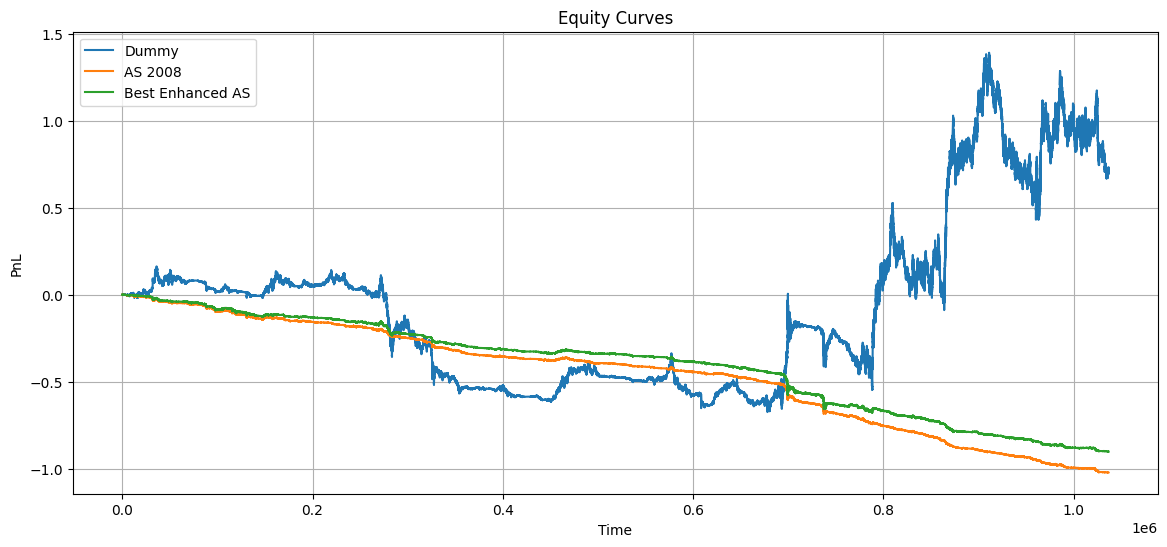

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    res_dummy["equity_curve"],
    label="Dummy"
)

plt.plot(
    res_as["equity_curve"],
    label="AS 2008"
)

plt.plot(
    res_best["equity_curve"],
    label="Best Enhanced AS"
)

plt.title("Equity Curves")

plt.xlabel("Time")
plt.ylabel("PnL")

plt.legend()

plt.grid(True)

plt.show()

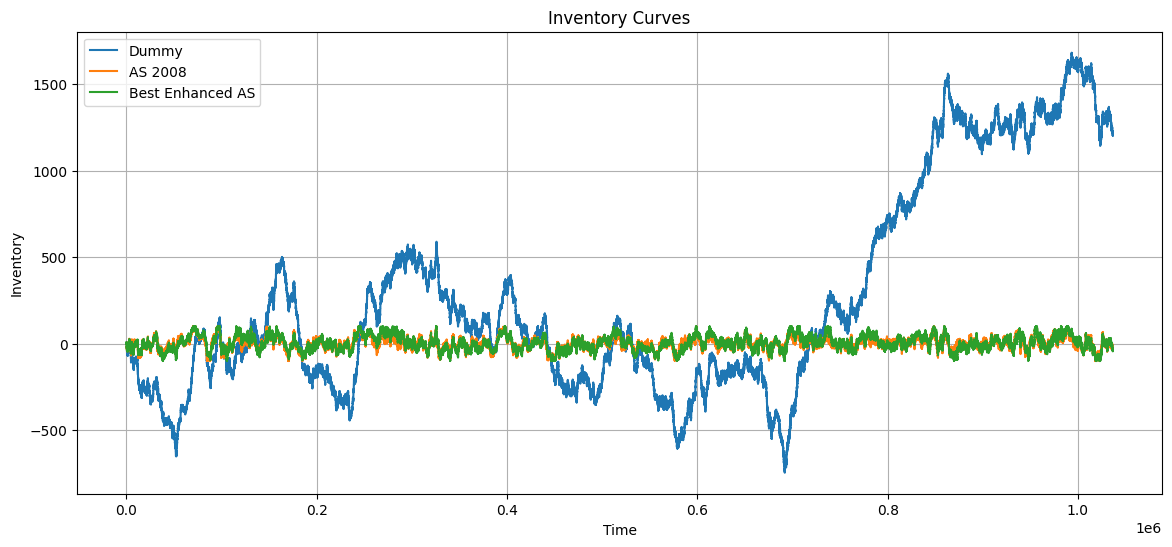

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    res_dummy["inventory_curve"],
    label="Dummy"
)

plt.plot(
    res_as["inventory_curve"],
    label="AS 2008"
)

plt.plot(
    res_best["inventory_curve"],
    label="Best Enhanced AS"
)

plt.title("Inventory Curves")

plt.xlabel("Time")
plt.ylabel("Inventory")

plt.legend()

plt.grid(True)

plt.show()

In [22]:
final_summary = pd.DataFrame([

    calc_metrics(
        res_dummy,
        "Dummy best bid/ask"
    ),

    calc_metrics(
        res_as,
        "Avellaneda-Stoikov 2008"
    ),

    calc_metrics(
        res_best,
        "Best Enhanced AS"
    )

])

final_summary = final_summary[[
    "strategy",

    "pnl",
    "turnover",
    "trades",

    "final_inventory",
    "inventory_std",

    "pnl_per_trade",
    "pnl_per_turnover",

    "max_drawdown",
    "equity_std"
]]

final_summary = final_summary.sort_values(
    "pnl",
    ascending=False
).reset_index(drop=True)

final_summary

,strategy,pnl,turnover,trades,final_inventory,inventory_std,pnl_per_trade,pnl_per_turnover,max_drawdown,equity_std
0,Dummy best bid/ask,0.720991,6238.272065,723717,1209.0,596.114154,9.962331e-07,0.000116,-0.960245,0.498774
1,Best Enhanced AS,-0.901777,4653.411860,536893,-39.0,41.573830,-1.679622e-06,-0.000194,-0.902177,0.266423
2,Avellaneda-Stoikov 2008,-1.022533,5041.512426,582806,-36.0,36.614132,-1.754499e-06,-0.000203,-1.022899,0.297208
